# NLP Course 2 Week 1 Lesson : Building The Model - Lecture Exercise 01
Estimated Time: 10 minutes
<br>
# Vocabulary Creation 
Create a tiny vocabulary from a tiny corpus
<br>
It's time to start small !
<br>
### Imports and Data

In [1]:
import re
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
# the tiny corpus of text ! 
text = 'red pink pink blue blue yellow ORANGE BLUE BLUE PINK' # 🌈
print(text)
print('string length : ',len(text))

red pink pink blue blue yellow ORANGE BLUE BLUE PINK
string length :  52


### Preprocessing

In [4]:
# convert all letters to lower case
text_lowercase = text.lower()
print(text_lowercase)
print('string length: ', len(text_lowercase))

red pink pink blue blue yellow orange blue blue pink
string length:  52


In [5]:
# some regex to tokenize the string to words and return them in a list
words = re.findall(r'\w+', text_lowercase)
print(words)
print('count: ', len(words))

['red', 'pink', 'pink', 'blue', 'blue', 'yellow', 'orange', 'blue', 'blue', 'pink']
count:  10


### Create Vocabulary
Option 1 : A set of distinct words from the text

In [6]:
# create vocab
vocab = set(words)
print(vocab)
print('count: ', len(vocab))

{'blue', 'yellow', 'pink', 'red', 'orange'}
count:  5


### Add Information with Word Counts
Option 2 : Two alternatives for including the word count as well

In [7]:
counts_a = dict()
for w in words:
    counts_a[w] = counts_a.get(w, 0) + 1
print(counts_a)
print('count: ', len(counts_a))

{'red': 1, 'pink': 3, 'blue': 4, 'yellow': 1, 'orange': 1}
count:  5


In [8]:
# create vocab including word count using collections.Counter
counts_b = dict()
counts_b = Counter(words)
print(counts_b)
print('counts: ', len(counts_b))

Counter({'blue': 4, 'pink': 3, 'red': 1, 'yellow': 1, 'orange': 1})
counts:  5


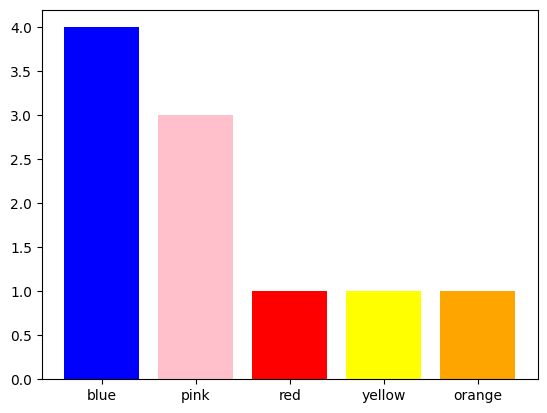

In [9]:
# barchart of sorted word counts
d = {'blue': counts_b['blue'], 'pink': counts_b['pink'], 'red': counts_b['red'], 'yellow': counts_b['yellow'], 'orange': counts_b['orange']}
plt.bar(range(len(d)), list(d.values()), align='center', color = d.keys())
_ = plt.xticks(range(len(d)), list(d.keys()))

In [10]:
# new corpus
# the tiny corpus of text ! 
text = 'red pink pink black BLACK blue blue yellow ORANGE BLUE BLUE PINK' # 🌈
print(text)
print('string length : ',len(text))


red pink pink black BLACK blue blue yellow ORANGE BLUE BLUE PINK
string length :  64


In [14]:
# convert all letters to lower case
text_lowercase = text.lower()
print(text_lowercase)
print('string length: ', len(text_lowercase))

red pink pink black black blue blue yellow orange blue blue pink
string length:  64


In [15]:
# some regex to tokenize the string to words and return them in a list
words = re.findall(r'\w+', text_lowercase)
print(words)
print('count: ', len(words))

['red', 'pink', 'pink', 'black', 'black', 'blue', 'blue', 'yellow', 'orange', 'blue', 'blue', 'pink']
count:  12


In [16]:
# create vocab including word count using collections.Counter
counts_b = dict()
counts_b = Counter(words)
print(counts_b)
print('counts: ', len(counts_b))

Counter({'blue': 4, 'pink': 3, 'black': 2, 'red': 1, 'yellow': 1, 'orange': 1})
counts:  6


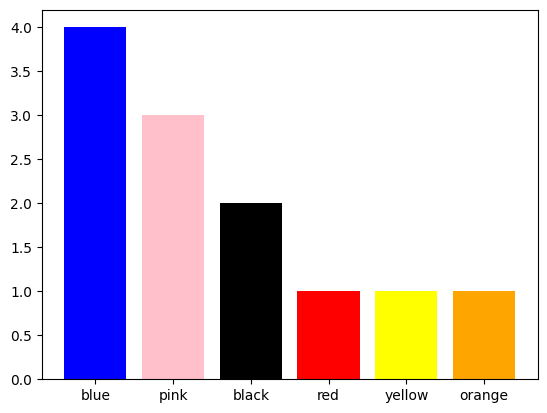

In [18]:
# barchart of sorted word counts
d = {'blue': counts_b['blue'], 'pink': counts_b['pink'], 'black': counts_b['black'],'red': counts_b['red'], 'yellow': counts_b['yellow'], 'orange': counts_b['orange']}
plt.bar(range(len(d)), list(d.values()), align='center', color = d.keys())
_ = plt.xticks(range(len(d)), list(d.keys()))

# NLP Course 2 Week 1 Lesson : Building The Model - Lecture Exercise 02
Estimated Time: 20 minutes
<br>
# Candidates from String Edits
Create a list of candidate strings by applying an edit operation
<br>
### Imports and Data

In [19]:
# data
word = 'dearz' # 🦌

### Splits
Find all the ways you can split a word into 2 parts !

In [22]:
splits_a = []
for i in range(len(word) + 1):
    splits_a.append([word[:i], word[i:]])

for i in splits_a:
    print(i)

['', 'dearz']
['d', 'earz']
['de', 'arz']
['dea', 'rz']
['dear', 'z']
['dearz', '']


In [24]:
# same splits, done using a list comprehension
splits_b = [(word[:i], word[i:]) for i in range(len(word)+1)]
for i in splits_b:
    print(i)

('', 'dearz')
('d', 'earz')
('de', 'arz')
('dea', 'rz')
('dear', 'z')
('dearz', '')


### Delete Edit
Delete a letter from each string in the `splits` list.
<br>
What this does is effectively delete each possible letter from the original word being edited. 

In [26]:
# deletes with a loop
splits = splits_a

print('word : ', word)
for L,R in splits:
    if R:
        print(L + R[1:], '<----- delete ', R[0])

word :  dearz
earz <----- delete  d
darz <----- delete  e
derz <----- delete  a
deaz <----- delete  r
dear <----- delete  z


In [27]:
# deletes with a list comprehension
splits = splits_a

print('word: ', word)
deletes = [L + R[1:] for L, R in splits if R ]

print(deletes)

word:  dearz
['earz', 'darz', 'derz', 'deaz', 'dear']


### Ungraded Exercise
You now have a list of ***candidate strings*** created after performing a **delete** edit.
<br>
Next step will be to filter this list for ***candidate words*** found in a vocabulary.
<br>
Given the example vocab below, can you think of a way to create a list of candidate words ? 
<br>
Remember, you already have a list of candidate strings, some of which are certainly not actual words you might find in your vocabulary !
<br>
<br>
So from the above list **earz, darz, derz, deaz, dear**. 
<br>
You're really only interested in **dear**.

In [28]:
vocab = ['dean','deer','dear','fries','and','coke']
edits = list(deletes)

print('vocab : ', vocab)
print('edits : ', edits)

### START CODE HERE ###
candidates = set.intersection(set(edits), set(vocab))  # hint: 'set.intersection'
### END CODE HERE ###

print('candidate words : ', candidates)

vocab :  ['dean', 'deer', 'dear', 'fries', 'and', 'coke']
edits :  ['earz', 'darz', 'derz', 'deaz', 'dear']
candidate words :  {'dear'}
